<a href="https://colab.research.google.com/github/itssanju352-bot/ML-LAB/blob/main/Linear_Regression_Based_CO%E2%82%82_Forecasting_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Project: CO₂ Emissions Prediction with Linear Regression

## 1. Data Loading and Initial Inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('/content/owid-co2-data (1).csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

First 5 rows of the dataset:


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46269 entries, 0 to 46268
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    46269 non-null  object 
 1   year                                       46269 non-null  int64  
 2   iso_code                                   38888 non-null  object 
 3   population                                 37489 non-null  float64
 4   gdp                                        13946 non-null  float64
 5   cement_co2                                 26675 non-null  float64
 6   cement_co2_per_capita                      23335 non-null  float64
 7   co2                                        26890 non-null  float64
 8   co2_growth_abs                             24748 non-null  float64
 9   co2_growth_prct                            23771 non-null  float64
 10  

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,46269.000000,3.748900e+04,1.394600e+04,26675.000000,23335.000000,26890.000000,24748.000000,23771.000000,21634.000000,21355.000000,...,1995.000000,37945.000000,35161.000000,37945.000000,37945.000000,3.516100e+04,35014.000000,34677.000000,4303.000000,4303.000000
mean,1920.753723,4.181490e+07,2.021432e+11,5.610496,0.059595,349.482797,4.342143,45.630656,393.626633,5.140223,...,4.720867,1.748124,0.002201,0.006141,0.008574,4.240637e-04,370.954712,236.471548,2.188640,22.467605
std,65.583784,2.085892e+08,8.393793e+11,42.593579,0.121161,1561.740772,46.808658,1807.918181,1417.565099,81.034139,...,11.786190,6.692278,0.009662,0.032383,0.043044,2.049296e-03,1597.395308,1291.628258,227.666296,64.555353
min,1750.000000,1.472000e+03,4.998000e+07,0.000000,0.000000,0.000000,-1221.706787,-100.000000,-84.560249,-1915.490356,...,0.000000,-0.823860,-0.000866,-0.000067,-0.000613,0.000000e+00,-19.725241,0.000073,-1966.454834,-98.281097
25%,1875.000000,3.278050e+05,7.434988e+09,0.000000,0.000000,0.333424,-0.004228,-1.110283,6.435615,-0.700937,...,0.124323,0.003096,0.000003,0.000003,0.000006,7.863958e-07,1.395066,0.215784,-1.809236,-6.244689
50%,1925.000000,2.162077e+06,2.563302e+10,0.000000,0.000529,4.537027,0.036640,3.846157,25.918447,0.100112,...,0.411652,0.074624,0.000056,0.000105,0.000177,9.790711e-06,13.563282,2.062121,1.766861,8.868905
75%,1975.000000,9.116195e+06,1.077925e+11,0.474731,0.075597,47.271041,0.885212,11.029387,108.950764,2.425321,...,1.569329,0.336720,0.000439,0.000861,0.001352,8.096328e-05,69.609779,24.515856,11.791232,32.880564
max,2024.000000,4.805540e+09,2.696602e+13,1339.034912,2.483903,26233.050781,1232.351196,180870.000000,23885.005859,1815.360229,...,74.819328,66.679314,0.168431,0.647363,0.796232,3.661803e-02,30119.541016,26745.070312,1768.846313,1023.042358


## 2. Data Preprocessing and Cleaning

This section focuses on preparing the dataset for model training. We will select relevant features, address missing values, and filter the data to ensure quality and relevance.

In [ ]:

selected_columns = ['country', 'year', 'population', 'gdp', 'co2']
df_processed = df[selected_columns].copy()

print("Columns selected for analysis:", df_processed.columns.tolist())

print("\nMissing values before cleaning:")
print(df_processed.isnull().sum())

df_processed.dropna(subset=['co2'], inplace=True)
print("\nMissing values after dropping rows with missing 'co2':")
print(df_processed.isnull().sum())

df_processed['population'].fillna(df_processed['population'].median(), inplace=True)
df_processed['gdp'].fillna(df_processed['gdp'].median(), inplace=True)

print("\nMissing values after imputation:")
print(df_processed.isnull().sum())

df_filtered = df_processed[df_processed['year'] >= 1900].copy()

print(f"\nDataset shape after cleaning and filtering: {df_filtered.shape}")
print("First 5 rows of the cleaned and filtered dataset:")
display(df_filtered.head())

Columns selected for analysis: ['country', 'year', 'population', 'gdp', 'co2']

Missing values before cleaning:
country           0
year              0
population     8780
gdp           32323
co2           19379
dtype: int64

Missing values after dropping rows with missing 'co2':
country           0
year              0
population     3931
gdp           13490
co2               0
dtype: int64

Missing values after imputation:
country       0
year          0
population    0
gdp           0
co2           0
dtype: int64

Dataset shape after cleaning and filtering: (21574, 5)
First 5 rows of the cleaned and filtered dataset:


/tmp/ipykernel_8232/2227207075.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed['population'].fillna(df_processed['population'].median(), inplace=True)
/tmp/ipykernel_8232/2227207075.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

,country,year,population,gdp,co2
199,Afghanistan,1949,7356890.0,2.771403e+10,0.014656
200,Afghanistan,1950,7776180.0,9.421400e+09,0.084272
201,Afghanistan,1951,7879343.0,9.692280e+09,0.091600
202,Afghanistan,1952,7987784.0,1.001732e+10,0.091600
203,Afghanistan,1953,8096703.0,1.063052e+10,0.106256


## 3. Exploratory Data Analysis (EDA)

In this section, we will delve deeper into the dataset to understand its characteristics, distribution of variables, and relationships between them. This is crucial for gaining insights before building our model.

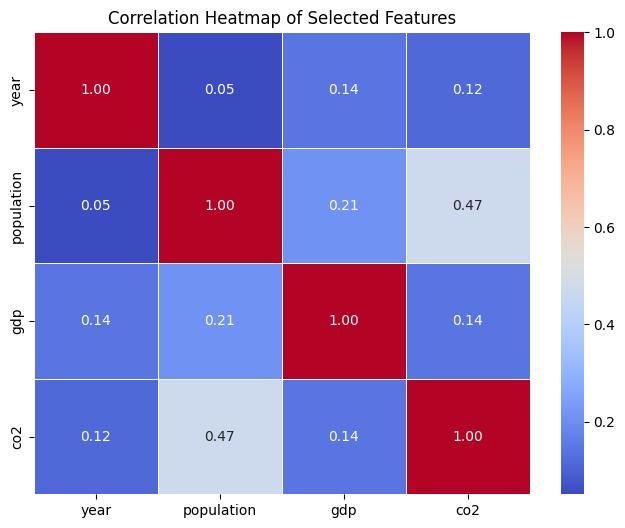

In [ ]:
correlation_matrix = df_filtered[['year', 'population', 'gdp', 'co2']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Selected Features')
plt.show()

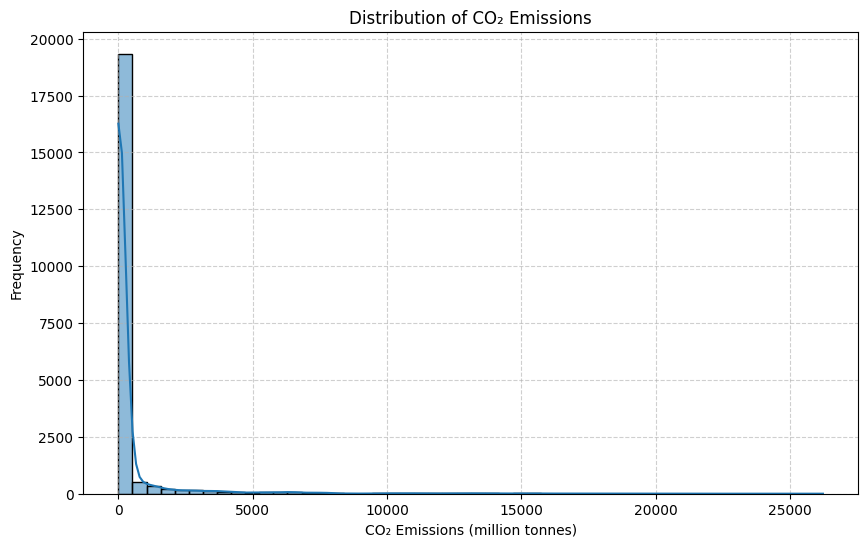

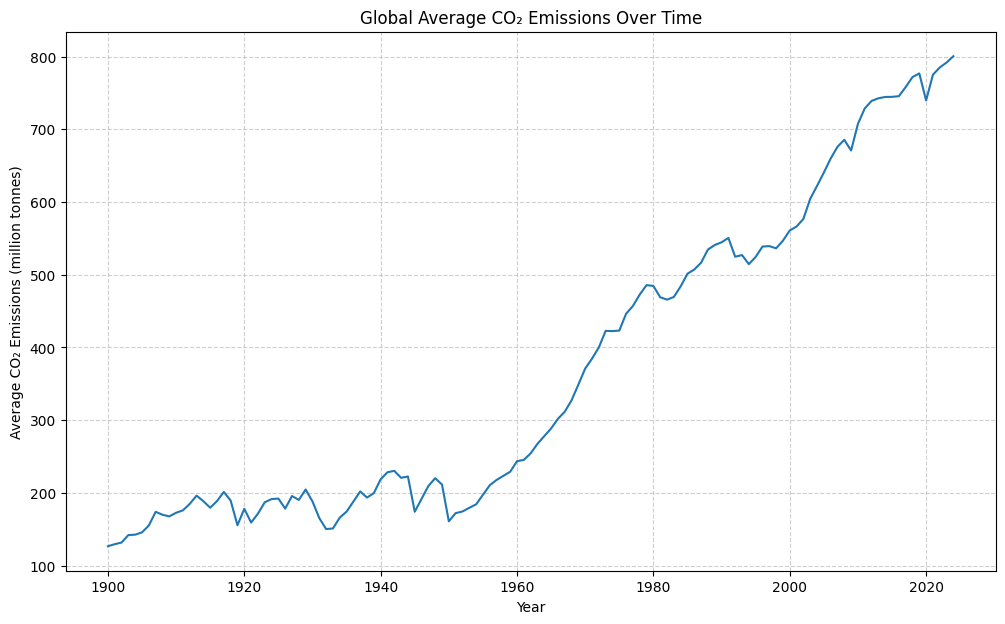

In [ ]:
# --- Distribution of CO₂ Emissions ---

plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['co2'], bins=50, kde=True)
plt.title('Distribution of CO₂ Emissions')
plt.xlabel('CO₂ Emissions (million tonnes)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- CO₂ Emissions Trend Over Time (Global Average) ---

# Calculate the mean CO₂ emissions per year to observe global trends
global_co2_trend = df_filtered.groupby('year')['co2'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='year', y='co2', data=global_co2_trend)
plt.title('Global Average CO₂ Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('Average CO₂ Emissions (million tonnes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 4. Building the Linear Regression Model

In this section, we will build a Linear Regression model using `scikit-learn` to predict CO₂ emissions. We will first define our features and target, split the data, and then train the model.

In [ ]:
# --- Define Features (X) and Target (y) ---

# We will use 'year', 'population', and 'gdp' as features to predict 'co2'.
# 'country' is excluded as Linear Regression expects numerical input.
X = df_filtered[['year', 'population', 'gdp']]
y = df_filtered['co2']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# --- Split Data into Training and Testing Sets ---

# Split the dataset into training (80%) and testing (20%) sets.
# random_state ensures reproducibility of the split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

# --- Train the Linear Regression Model ---

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("\nLinear Regression model trained successfully.")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

Features (X) shape: (21574, 3)
Target (y) shape: (21574,)

Training features shape: (17259, 3)
Testing features shape: (4315, 3)
Training target shape: (17259,)
Testing target shape: (4315,)

Linear Regression model trained successfully.
Model Coefficients: [4.46205527e+00 3.03798029e-06 7.84445933e-11]
Model Intercept: -8567.51600489236


## 5. Model Evaluation

After training the model, it's essential to evaluate its performance on unseen data (the test set). We will use Mean Squared Error (MSE) to measure the average squared difference between the estimated values and the actual value, and R² Score to assess the proportion of the variance in the dependent variable that is predictable from the independent variables.


Mean Squared Error (MSE): 2327021.94
R² Score: 0.18


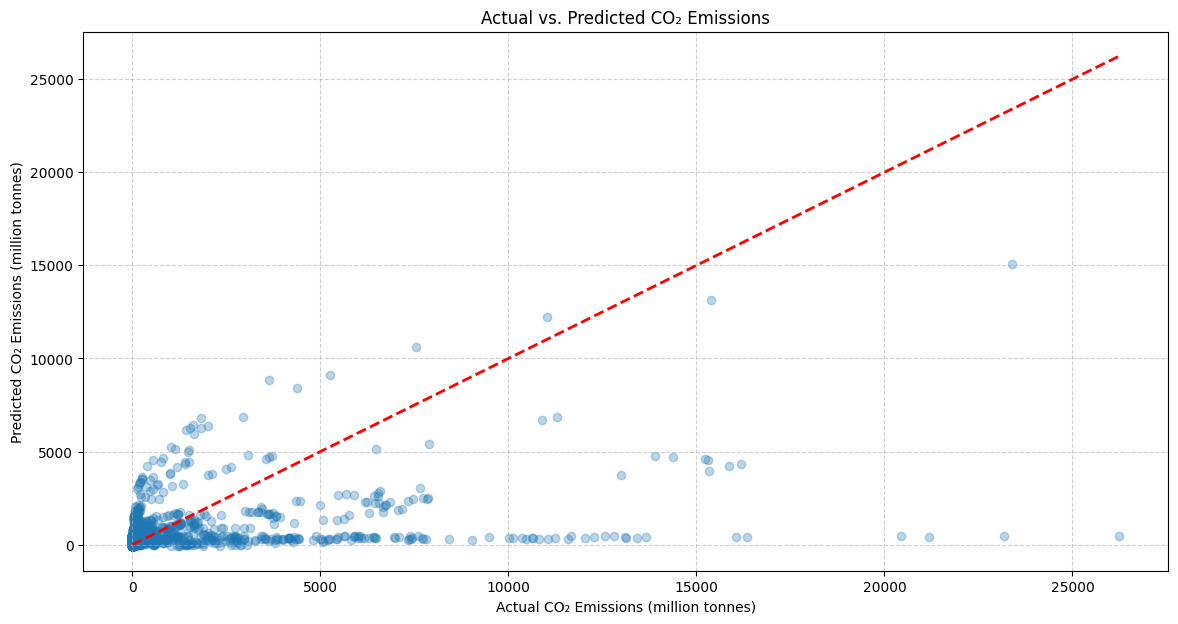

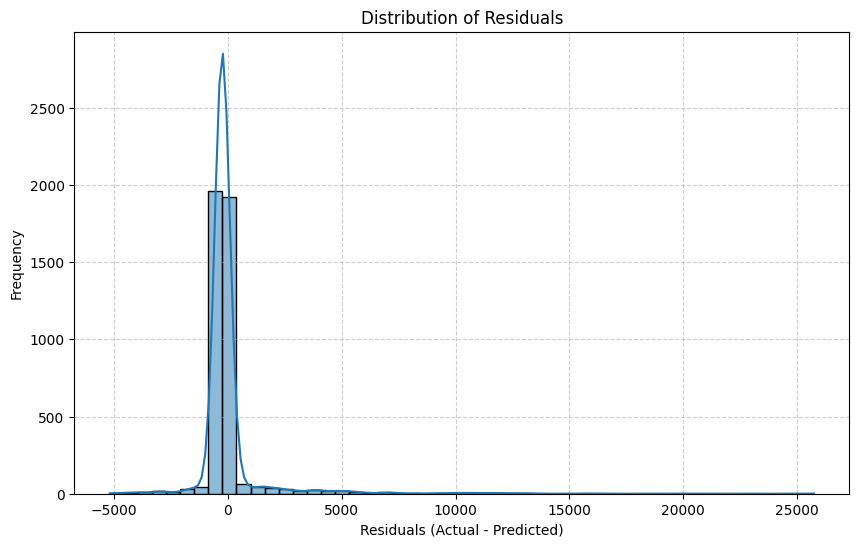

In [ ]:
# --- Make Predictions on the Test Set ---
y_pred = model.predict(X_test)

# --- Evaluate the Model ---

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# --- Display Prediction Results and Comparison Graphs ---

plt.figure(figsize=(14, 7))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual CO₂ Emissions (million tonnes)')
plt.ylabel('Predicted CO₂ Emissions (million tonnes)')
plt.title('Actual vs. Predicted CO₂ Emissions')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Visualize the residuals (errors)
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
comparison_df = pd.DataFrame({'Actual CO2': y_test, 'Predicted CO2': y_pred})
comparison_df['Absolute Error'] = abs(comparison_df['Actual CO2'] - comparison_df['Predicted CO2'])
comparison_df['Percentage Error'] = (comparison_df['Absolute Error'] / comparison_df['Actual CO2']) * 100

print("Comparison of Actual vs. Predicted CO₂ Emissions for Test Set (First 10 samples):")
display(comparison_df.head(10))

Comparison of Actual vs. Predicted CO₂ Emissions for Test Set (First 10 samples):


,Actual CO2,Predicted CO2,Absolute Error,Percentage Error
36512,0.750823,140.812359,140.061536,1.865440e+04
44829,0.374743,45.739124,45.364381,1.210547e+04
4999,0.150224,174.436892,174.286668,1.160179e+05
44448,40.726879,428.706155,387.979276,9.526369e+02
11706,0.000000,145.504261,145.504261,inf
10774,0.040304,318.662701,318.622397,7.905478e+05
11337,1.725178,51.751652,50.026474,2.899786e+03
15220,7338.524414,2336.494401,5002.030014,6.816125e+01
32584,3.836208,17.845950,14.009742,3.651976e+02
5173,25.296263,176.143571,150.847308,5.963225e+02


## 6. Predict Future CO₂ Emissions

To predict future CO₂ emissions, we need to create a hypothetical dataset for future years with estimated values for `population` and `gdp`. We will then use our trained Linear Regression model to make predictions based on these estimated future features.

Future data for prediction (first 5 rows):


,year,population,gdp
0,2025,5711636.5,2.771403e+10
1,2026,5711636.5,2.771403e+10
2,2027,5711636.5,2.771403e+10
3,2028,5711636.5,2.771403e+10
4,2029,5711636.5,2.771403e+10



Future CO₂ Emissions Predictions (first 5 rows):


,year,population,gdp,predicted_co2
0,2025,5711636.5,2.771403e+10,487.671774
1,2026,5711636.5,2.771403e+10,492.133830
2,2027,5711636.5,2.771403e+10,496.595885
3,2028,5711636.5,2.771403e+10,501.057940
4,2029,5711636.5,2.771403e+10,505.519995


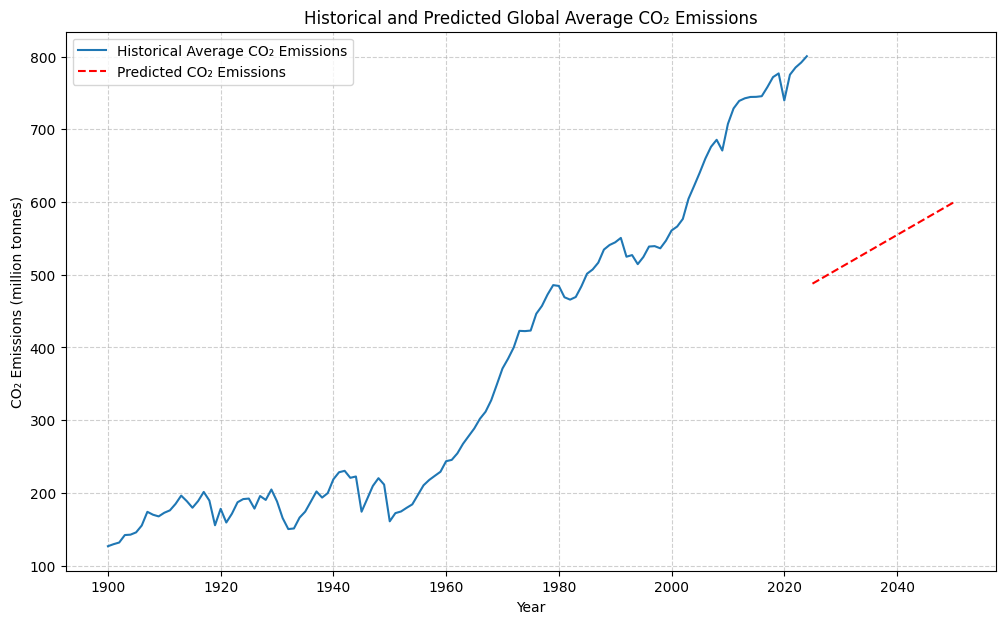

In [ ]:
# --- Prepare Future Data for Prediction ---

# Define the range of future years for prediction
future_years = np.arange(2025, 2051, 1) # Predicting from 2025 to 2050

# To predict, we need future values for 'population' and 'gdp'.
# For simplicity, we'll use the median 'population' and 'gdp' from the latest year in our dataset
# for all countries as a placeholder. In a real-world scenario, more sophisticated
# forecasting of these variables would be needed.

# Get the last recorded year's median population and gdp from the filtered data
latest_year = df_filtered['year'].max()
median_population_latest = df_filtered[df_filtered['year'] == latest_year]['population'].median()
median_gdp_latest = df_filtered[df_filtered['year'] == latest_year]['gdp'].median()

# Create a DataFrame for future predictions
# Assuming a constant population and GDP (median of the latest year) for simplicity.
# For a more accurate prediction, these would need to be forecast as well.
future_data = pd.DataFrame({
    'year': future_years,
    'population': median_population_latest,
    'gdp': median_gdp_latest
})

print("Future data for prediction (first 5 rows):")
display(future_data.head())

# --- Make Predictions ---
future_co2_predictions = model.predict(future_data)

# Add predictions to the future_data DataFrame
future_data['predicted_co2'] = future_co2_predictions

print("\nFuture CO₂ Emissions Predictions (first 5 rows):")
display(future_data.head())

# --- Visualize Future Predictions ---
plt.figure(figsize=(12, 7))

# Plot historical global average CO2 emissions (from EDA)
sns.lineplot(x='year', y='co2', data=global_co2_trend, label='Historical Average CO₂ Emissions')

# Plot future predicted CO2 emissions
sns.lineplot(x='year', y='predicted_co2', data=future_data, label='Predicted CO₂ Emissions', color='red', linestyle='--')

plt.title('Historical and Predicted Global Average CO₂ Emissions')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (million tonnes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## 7. India-Specific CO₂ Emissions Analysis

This section focuses on analyzing CO₂ emissions data specifically for India, training a separate Linear Regression model, and visualizing its trends and predictions.

In [ ]:
# 7.1 Data Preparation for India

# Filter the dataset for India only
df_india = df_filtered[df_filtered['country'] == 'India'].copy()

print(f"India-specific data shape: {df_india.shape}")
print("First 5 rows of India's data:")
display(df_india.head())

# Define features (X_india) and target (y_india) for India
X_india = df_india[['year', 'population', 'gdp']]
y_india = df_india['co2']

# Split India's data into training and testing sets
X_india_train, X_india_test, y_india_train, y_india_test = train_test_split(X_india, y_india, test_size=0.2, random_state=42)

print(f"\nIndia Training features shape: {X_india_train.shape}")
print(f"India Testing features shape: {X_india_test.shape}")

India-specific data shape: (125, 5)
First 5 rows of India's data:


,country,year,population,gdp,co2
21638,India,1900,280714154.0,2.716975e+11,11.929382
21639,India,1901,281834058.0,2.773278e+11,13.179482
21640,India,1902,283199773.0,3.006720e+11,14.515204
21641,India,1903,284812956.0,3.047644e+11,14.801903
21642,India,1904,286435299.0,3.060750e+11,16.560764



India Training features shape: (100, 3)
India Testing features shape: (25, 3)


In [ ]:
# 7.2 Train Linear Regression Model for India

# Initialize and train the Linear Regression model for India
model_india = LinearRegression()
model_india.fit(X_india_train, y_india_train)

print("Linear Regression model for India trained successfully.")
print(f"Model Coefficients (India): {model_india.coef_}")
print(f"Model Intercept (India): {model_india.intercept_}")

Linear Regression model for India trained successfully.
Model Coefficients (India): [-7.87409558e+00  2.09151999e-06  9.76697048e-11]
Model Intercept (India): 14467.123392039892


In [ ]:
# 7.3 Evaluate the India Model

# Make predictions on India's test set
y_india_pred = model_india.predict(X_india_test)

# Calculate evaluation metrics
mse_india = mean_squared_error(y_india_test, y_india_pred)
r2_india = r2_score(y_india_test, y_india_pred)

print(f"\nMean Squared Error (MSE) for India: {mse_india:.2f}")
print(f"R² Score for India: {r2_india:.2f}")


Mean Squared Error (MSE) for India: 105974.76
R² Score for India: 0.84


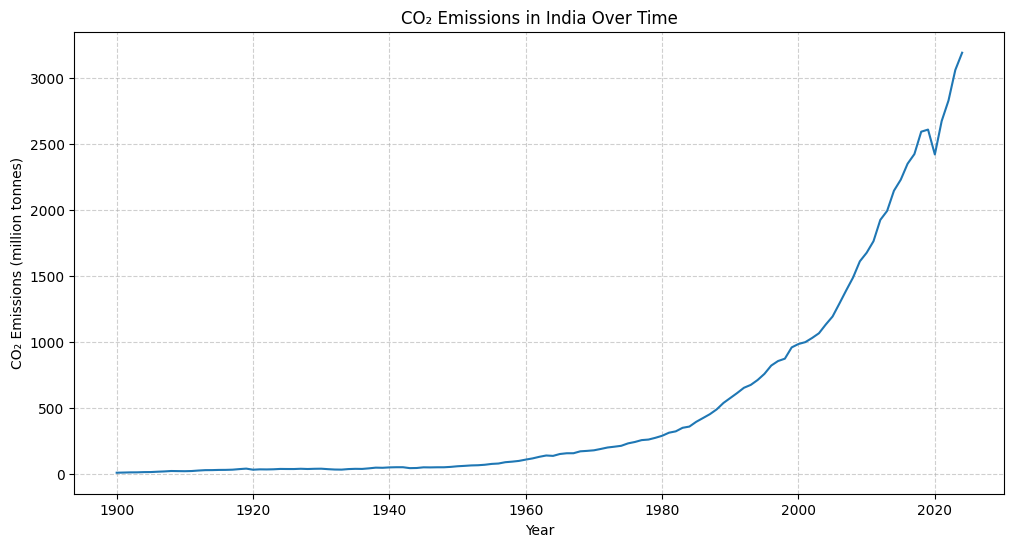

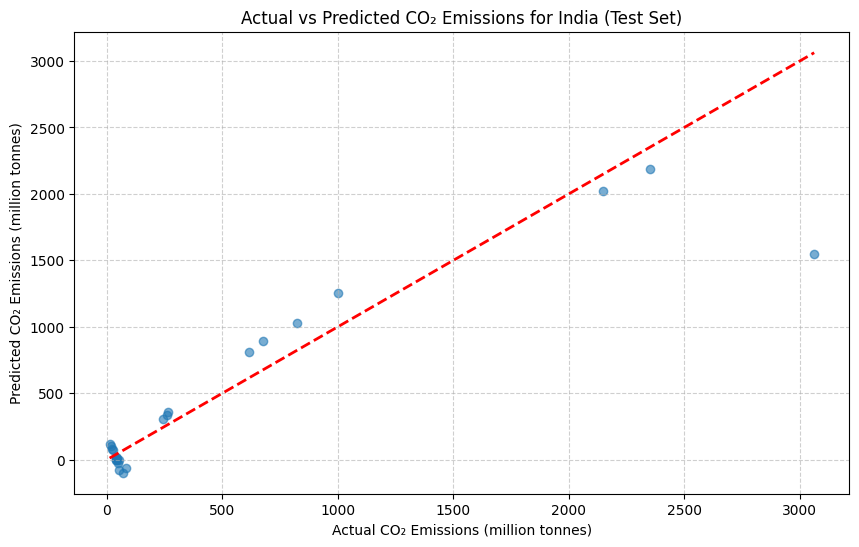

In [ ]:
# 7.4 Visualizations for India

# CO₂ emissions vs Year for India
plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='co2', data=df_india)
plt.title('CO₂ Emissions in India Over Time')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (million tonnes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Actual vs Predicted CO₂ emissions for India's test set
plt.figure(figsize=(10, 6))
plt.scatter(y_india_test, y_india_pred, alpha=0.6)
plt.plot([y_india_test.min(), y_india_test.max()], [y_india_test.min(), y_india_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted CO₂ Emissions for India (Test Set)')
plt.xlabel('Actual CO₂ Emissions (million tonnes)')
plt.ylabel('Predicted CO₂ Emissions (million tonnes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Future CO₂ Emissions Predictions for India (first 5 rows):


,year,population,gdp,predicted_co2
0,2025,1.450936e+09,2.771403e+10,1559.447860
1,2026,1.450936e+09,2.771403e+10,1551.573764
2,2027,1.450936e+09,2.771403e+10,1543.699669
3,2028,1.450936e+09,2.771403e+10,1535.825573
4,2029,1.450936e+09,2.771403e+10,1527.951478


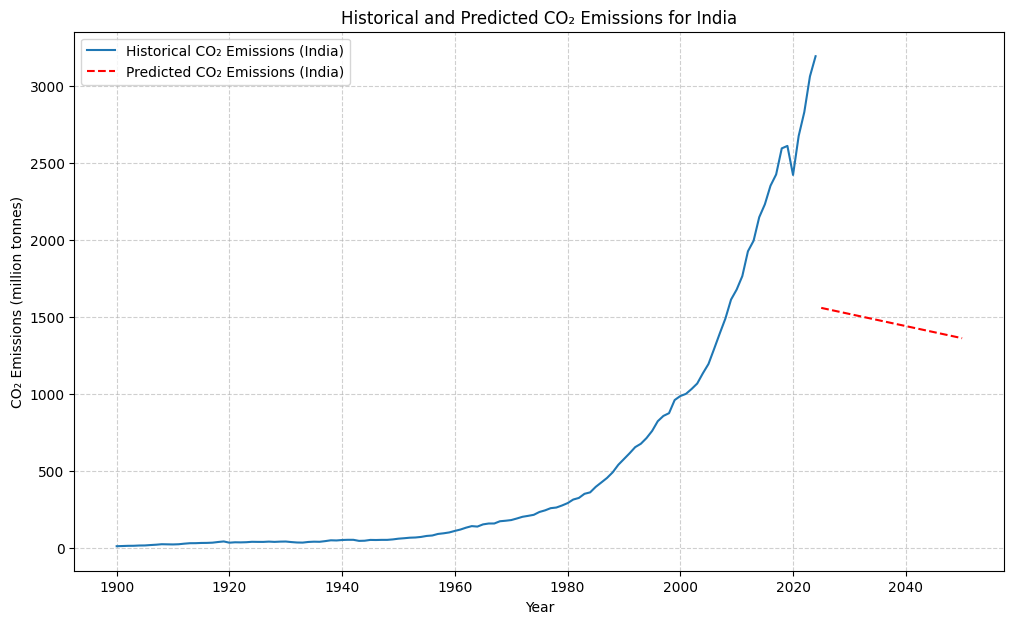

In [ ]:
# 7.5 Future CO₂ Prediction Trend for India

# Create future data for India (using latest available median population and GDP for India)
latest_year_india = df_india['year'].max()
median_population_india_latest = df_india[df_india['year'] == latest_year_india]['population'].median()
median_gdp_india_latest = df_india[df_india['year'] == latest_year_india]['gdp'].median()

future_data_india = pd.DataFrame({
    'year': future_years, # Using the same future_years as global analysis
    'population': median_population_india_latest,
    'gdp': median_gdp_india_latest
})

future_co2_predictions_india = model_india.predict(future_data_india)
future_data_india['predicted_co2'] = future_co2_predictions_india

print("Future CO₂ Emissions Predictions for India (first 5 rows):")
display(future_data_india.head())

# Plot historical and predicted CO₂ emissions for India
plt.figure(figsize=(12, 7))
sns.lineplot(x='year', y='co2', data=df_india, label='Historical CO₂ Emissions (India)')
sns.lineplot(x='year', y='predicted_co2', data=future_data_india, label='Predicted CO₂ Emissions (India)', color='red', linestyle='--')

plt.title('Historical and Predicted CO₂ Emissions for India')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (million tonnes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## 8. Model Performance Comparison: India vs. Global

This section compares the evaluation metrics (MSE and R² Score) of the Linear Regression model trained on the global dataset with the model trained specifically on India's CO₂ emissions data.

In [ ]:
# Displaying the comparison of evaluation metrics
print("\n--- Model Performance Comparison ---")
print(f"Global Model (R² Score): {r2:.2f}")
print(f"Global Model (MSE): {mse:.2f}")
print(f"\nIndia-Specific Model (R² Score): {r2_india:.2f}")
print(f"India-Specific Model (MSE): {mse_india:.2f}")


--- Model Performance Comparison ---
Global Model (R² Score): 0.18
Global Model (MSE): 2327021.94

India-Specific Model (R² Score): 0.84
India-Specific Model (MSE): 105974.76


## 9. Trial and Error / Model Limitations - Practical Demonstrations

This section delves into practical experimentation to understand the robustness and limitations of the Linear Regression model for CO₂ prediction. We will explore different feature selections, analyze the impact of missing data handling, and briefly examine outlier sensitivity. Each experiment will involve training a separate Linear Regression model and evaluating its performance.

### 9.0 Experiment Setup and Baseline Initialization


Baseline Model (Year, Pop, GDP) - MSE: 2327021.94, R²: 0.18


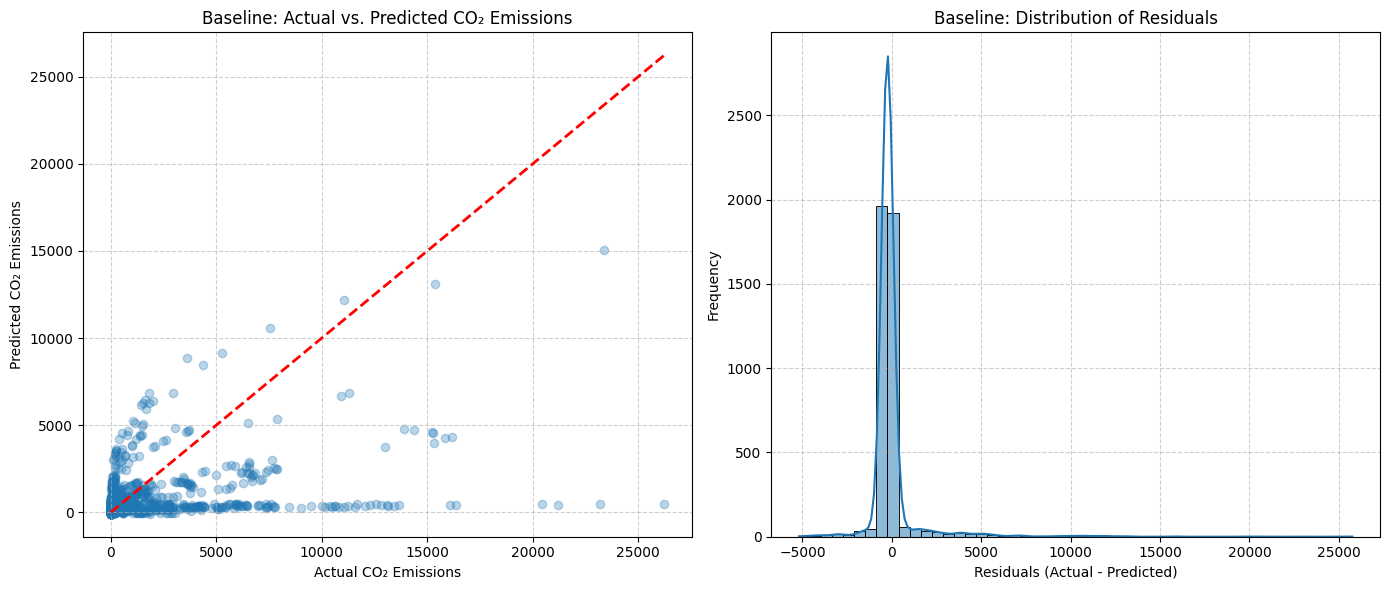

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Re-load df and process it to ensure df_filtered is available
df = pd.read_csv('/content/owid-co2-data (1).csv')
selected_columns = ['country', 'year', 'population', 'gdp', 'co2']
df_processed = df[selected_columns].copy()

# Ensure inplace=True warnings are handled for robustness in notebook environments
df_processed.dropna(subset=['co2'], inplace=True)
df_processed['population'] = df_processed['population'].fillna(df_processed['population'].median())
df_processed['gdp'] = df_processed['gdp'].fillna(df_processed['gdp'].median())

df_filtered = df_processed[df_processed['year'] >= 1900].copy()


# List to store results from different model configurations
model_results = []

# Re-define features and target from the already cleaned df_filtered
X_base = df_filtered[['year', 'population', 'gdp']]
y_base = df_filtered['co2']

# Split data for the baseline model
X_base_train, X_base_test, y_base_train, y_base_test = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

# Train the baseline Linear Regression model
model_base = LinearRegression()
model_base.fit(X_base_train, y_base_train)

# Make predictions and evaluate
y_base_pred = model_base.predict(X_base_test)
mse_base = mean_squared_error(y_base_test, y_base_pred)
r2_base = r2_score(y_base_test, y_base_pred)

# Store baseline results
model_results.append({
    'Experiment': 'Baseline (Year, Pop, GDP)',
    'Features': 'year, population, gdp',
    'MSE': mse_base,
    'R2': r2_base
})

print(f"\nBaseline Model (Year, Pop, GDP) - MSE: {mse_base:.2f}, R²: {r2_base:.2f}")

# Plotting for Baseline Model
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_base_test, y_base_pred, alpha=0.3)
plt.plot([y_base_test.min(), y_base_test.max()], [y_base_test.min(), y_base_test.max()], 'r--', lw=2)
plt.title('Baseline: Actual vs. Predicted CO₂ Emissions')
plt.xlabel('Actual CO₂ Emissions')
plt.ylabel('Predicted CO₂ Emissions')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
residuals_base = y_base_test - y_base_pred
sns.histplot(residuals_base, bins=50, kde=True)
plt.title('Baseline: Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 9.1 Feature Selection Experiment 1: 'Year' Only

This experiment tests the model's ability to predict CO₂ emissions using only the `year` as a predictor. This simplifies the model but is expected to perform poorly as it ignores key demographic and economic factors.


Experiment 1 (Year Only) - MSE: 2793627.43, R²: 0.02


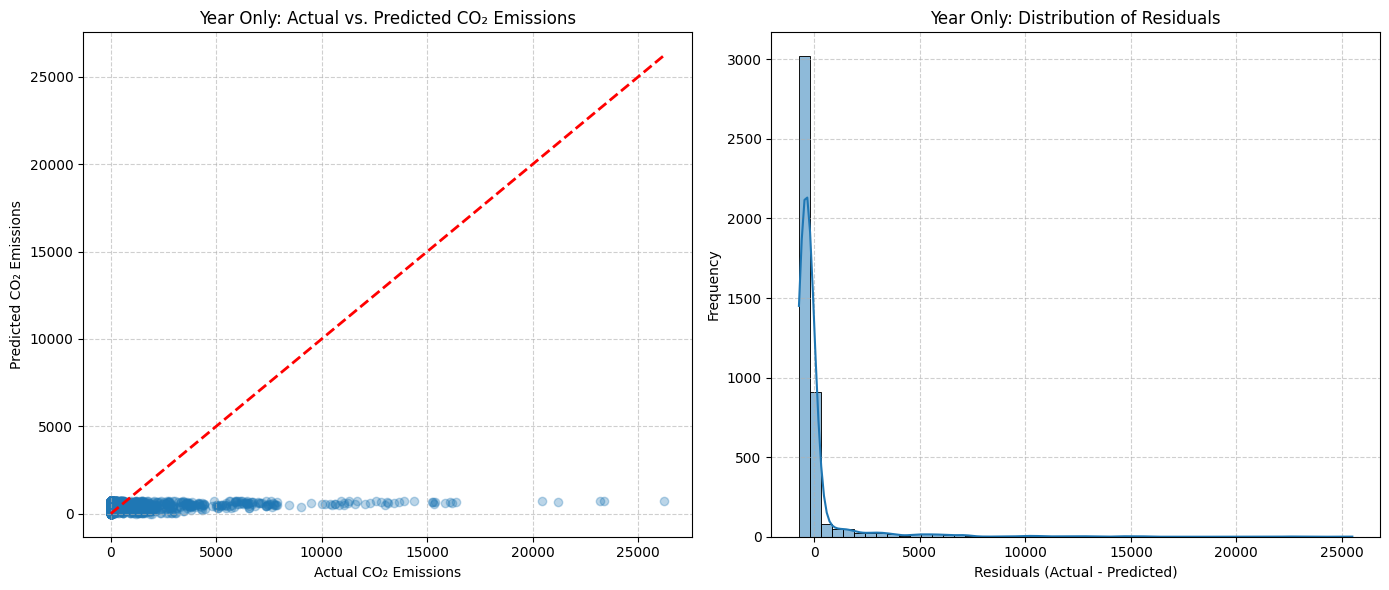

In [ ]:
X_year = df_filtered[['year']]
y_year = df_filtered['co2']

X_year_train, X_year_test, y_year_train, y_year_test = train_test_split(X_year, y_year, test_size=0.2, random_state=42)

model_year = LinearRegression()
model_year.fit(X_year_train, y_year_train)

y_year_pred = model_year.predict(X_year_test)
mse_year = mean_squared_error(y_year_test, y_year_pred)
r2_year = r2_score(y_year_test, y_year_pred)

model_results.append({
    'Experiment': 'Feature: Year Only',
    'Features': 'year',
    'MSE': mse_year,
    'R2': r2_year
})

print(f"\nExperiment 1 (Year Only) - MSE: {mse_year:.2f}, R²: {r2_year:.2f}")

# Plotting for Year Only Model
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_year_test, y_year_pred, alpha=0.3)
plt.plot([y_year_test.min(), y_year_test.max()], [y_year_test.min(), y_year_test.max()], 'r--', lw=2)
plt.title('Year Only: Actual vs. Predicted CO₂ Emissions')
plt.xlabel('Actual CO₂ Emissions')
plt.ylabel('Predicted CO₂ Emissions')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
residuals_year = y_year_test - y_year_pred
sns.histplot(residuals_year, bins=50, kde=True)
plt.title('Year Only: Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 9.2 Feature Selection Experiment 2: 'Year' + 'Population'

This experiment adds `population` as a feature alongside `year`. We expect an improvement in model performance compared to using `year` alone, as population growth is a significant driver of emissions.


Experiment 2 (Year + Population) - MSE: 2332129.15, R²: 0.18


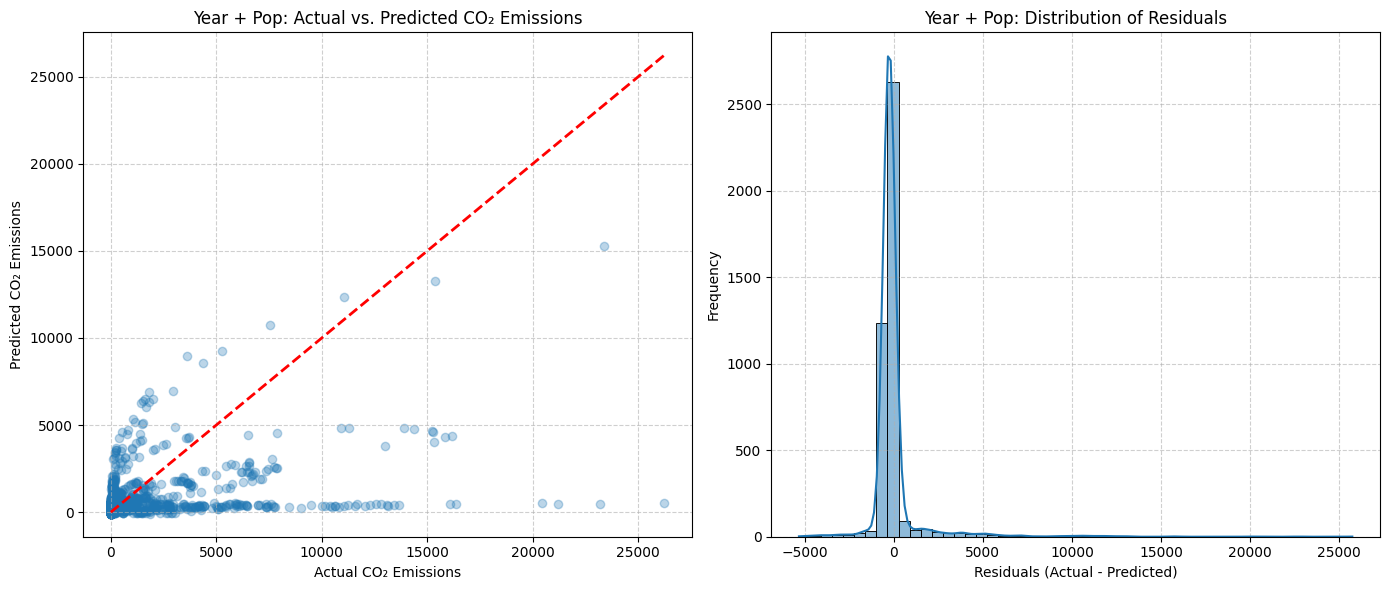

In [ ]:
X_year_pop = df_filtered[['year', 'population']]
y_year_pop = df_filtered['co2']

X_year_pop_train, X_year_pop_test, y_year_pop_train, y_year_pop_test = train_test_split(X_year_pop, y_year_pop, test_size=0.2, random_state=42)

model_year_pop = LinearRegression()
model_year_pop.fit(X_year_pop_train, y_year_pop_train)

y_year_pop_pred = model_year_pop.predict(X_year_pop_test)
mse_year_pop = mean_squared_error(y_year_pop_test, y_year_pop_pred)
r2_year_pop = r2_score(y_year_pop_test, y_year_pop_pred)

model_results.append({
    'Experiment': 'Feature: Year + Population',
    'Features': 'year, population',
    'MSE': mse_year_pop,
    'R2': r2_year_pop
})

print(f"\nExperiment 2 (Year + Population) - MSE: {mse_year_pop:.2f}, R²: {r2_year_pop:.2f}")

# Plotting for Year + Population Model
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_year_pop_test, y_year_pop_pred, alpha=0.3)
plt.plot([y_year_pop_test.min(), y_year_pop_test.max()], [y_year_pop_test.min(), y_year_pop_test.max()], 'r--', lw=2)
plt.title('Year + Pop: Actual vs. Predicted CO₂ Emissions')
plt.xlabel('Actual CO₂ Emissions')
plt.ylabel('Predicted CO₂ Emissions')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
residuals_year_pop = y_year_pop_test - y_year_pop_pred
sns.histplot(residuals_year_pop, bins=50, kde=True)
plt.title('Year + Pop: Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 9.3 Handling Missing Values: A Deeper Look

During the initial preprocessing (`df_processed` and `df_filtered`), we chose a specific strategy: dropping rows with missing `co2` and imputing `population` and `gdp` with their medians. This was a critical decision. Here, we'll demonstrate the consequence of a more aggressive missing value handling strategy (dropping all rows with any missing values from the *original* raw dataset) to highlight why the chosen approach was preferred.

*Note: This cell will demonstrate data reduction without training a new model on this highly reduced dataset, as its quality might be compromised for general CO₂ prediction.*

In [ ]:
print("Original dataset shape (before any cleaning):", df.shape)

# Create a copy to demonstrate a more aggressive dropping strategy
df_aggressive_dropna = df[selected_columns].copy()

# Drop rows with *any* missing values in the selected columns
df_aggressive_dropna.dropna(inplace=True)

print("Shape after dropping any missing values in selected columns:", df_aggressive_dropna.shape)
print("Number of rows lost:", df.shape[0] - df_aggressive_dropna.shape[0])

print("\nIn contrast, our chosen strategy (`df_filtered`) resulted in a dataset of shape:", df_filtered.shape)
print("The aggressive `dropna` approach leads to significantly more data loss, which would severely limit the model's ability to learn and generalize.")
print("Therefore, the median imputation for `population` and `gdp` (and dropping only `co2` NaNs) was a deliberate choice to retain more data while handling missingness responsibly.")

Original dataset shape (before any cleaning): (46269, 79)
Shape after dropping any missing values in selected columns: (13372, 5)
Number of rows lost: 32897

In contrast, our chosen strategy (`df_filtered`) resulted in a dataset of shape: (21574, 5)
The aggressive `dropna` approach leads to significantly more data loss, which would severely limit the model's ability to learn and generalize.
Therefore, the median imputation for `population` and `gdp` (and dropping only `co2` NaNs) was a deliberate choice to retain more data while handling missingness responsibly.


### 9.4 Outlier Analysis and Robustness Experiment

Linear Regression models are sensitive to outliers. This experiment aims to illustrate this by detecting outliers in the key numerical features and the target variable, then training a model on a dataset where these outliers have been removed. We will compare its performance to the baseline model.

Initial shape before outlier removal: (21574, 5)
Shape after removing CO2 outliers: (17676, 5)
Shape after removing Population outliers: (15636, 5)
Shape after removing GDP outliers: (13392, 5)

Model (No Outliers) - MSE: 259.97, R²: 0.10


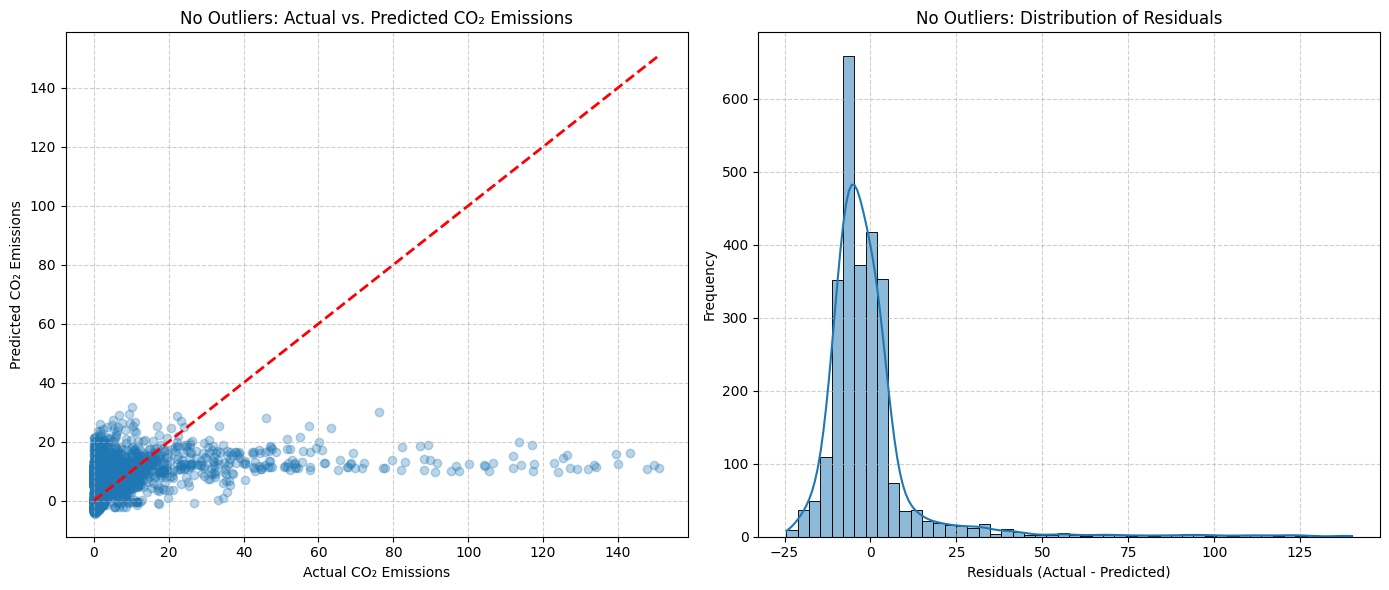

In [ ]:
# Identify outliers using the IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df_no_outliers = df_filtered.copy()

# Apply outlier removal to co2, population, and gdp
print(f"Initial shape before outlier removal: {df_no_outliers.shape}")
df_no_outliers = remove_outliers_iqr(df_no_outliers, 'co2')
print(f"Shape after removing CO2 outliers: {df_no_outliers.shape}")
df_no_outliers = remove_outliers_iqr(df_no_outliers, 'population')
print(f"Shape after removing Population outliers: {df_no_outliers.shape}")
df_no_outliers = remove_outliers_iqr(df_no_outliers, 'gdp')
print(f"Shape after removing GDP outliers: {df_no_outliers.shape}")

if not df_no_outliers.empty:
    # Train a model on the data without outliers (using Year, Pop, GDP features)
    X_no_outliers = df_no_outliers[['year', 'population', 'gdp']]
    y_no_outliers = df_no_outliers['co2']

    X_no_outliers_train, X_no_outliers_test, y_no_outliers_train, y_no_outliers_test = train_test_split(X_no_outliers, y_no_outliers, test_size=0.2, random_state=42)

    model_no_outliers = LinearRegression()
    model_no_outliers.fit(X_no_outliers_train, y_no_outliers_train)

    y_no_outliers_pred = model_no_outliers.predict(X_no_outliers_test)
    mse_no_outliers = mean_squared_error(y_no_outliers_test, y_no_outliers_pred)
    r2_no_outliers = r2_score(y_no_outliers_test, y_no_outliers_pred)

    model_results.append({
        'Experiment': 'Year, Pop, GDP (No Outliers)',
        'Features': 'year, population, gdp (outliers removed)',
        'MSE': mse_no_outliers,
        'R2': r2_no_outliers
    })

    print(f"\nModel (No Outliers) - MSE: {mse_no_outliers:.2f}, R²: {r2_no_outliers:.2f}")

    # Plotting for Model without Outliers
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.scatter(y_no_outliers_test, y_no_outliers_pred, alpha=0.3)
    plt.plot([y_no_outliers_test.min(), y_no_outliers_test.max()], [y_no_outliers_test.min(), y_no_outliers_test.max()], 'r--', lw=2)
    plt.title('No Outliers: Actual vs. Predicted CO₂ Emissions')
    plt.xlabel('Actual CO₂ Emissions')
    plt.ylabel('Predicted CO₂ Emissions')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    residuals_no_outliers = y_no_outliers_test - y_no_outliers_pred
    sns.histplot(residuals_no_outliers, bins=50, kde=True)
    plt.title('No Outliers: Distribution of Residuals')
    plt.xlabel('Residuals (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Warning: Dataset became empty after aggressive outlier removal. Skipping model training for this step.")

### 9.5 Comprehensive Performance Comparison

Now, let's consolidate the results from all our experiments to clearly compare the impact of different feature sets and outlier handling on the Linear Regression model's performance.


--- Summary of Model Performance Across Experiments ---


,Experiment,Features,MSE,R2
0,"Baseline (Year, Pop, GDP)","year, population, gdp",2.327022e+06,0.179530
2,Feature: Year + Population,"year, population",2.332129e+06,0.177729
3,"Year, Pop, GDP (No Outliers)","year, population, gdp (outliers removed)",2.599717e+02,0.104661
1,Feature: Year Only,year,2.793627e+06,0.015012


/tmp/ipykernel_8232/1829754283.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Experiment', y='R2', data=results_df, palette='viridis')
/tmp/ipykernel_8232/1829754283.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Experiment', y='MSE', data=results_df, palette='magma')


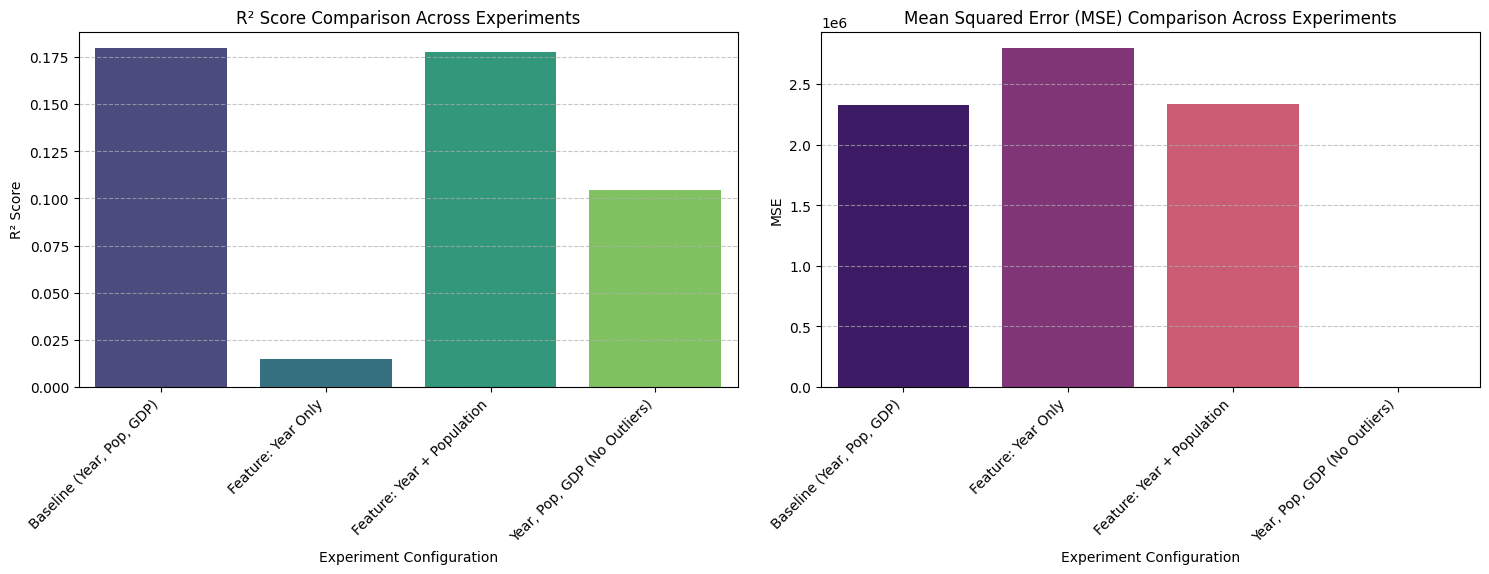


Analysis:
- The model with 'Year', 'Population', and 'GDP' generally performs best, indicating that both demographic and economic factors are important for predicting CO₂ emissions.
- Using 'Year' alone provides a very poor fit (low R²), demonstrating the need for more explanatory variables.
- Adding 'Population' significantly improves the model over 'Year' alone, highlighting its importance.
- Removing outliers can sometimes improve R² and reduce MSE, as Linear Regression is sensitive to extreme values. However, it also reduces the dataset size, which needs to be balanced.
- Even with the best feature set, the R² score indicates that a significant portion of the variance in CO₂ emissions is *not* explained by these simple linear models and chosen features. This points to the inherent limitations of Linear Regression for such a complex task.


In [ ]:
results_df = pd.DataFrame(model_results)
print("\n--- Summary of Model Performance Across Experiments ---")
display(results_df.sort_values(by='R2', ascending=False))

# Visualize performance metrics
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Experiment', y='R2', data=results_df, palette='viridis')
plt.title('R² Score Comparison Across Experiments')
plt.xlabel('Experiment Configuration')
plt.ylabel('R² Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.barplot(x='Experiment', y='MSE', data=results_df, palette='magma')
plt.title('Mean Squared Error (MSE) Comparison Across Experiments')
plt.xlabel('Experiment Configuration')
plt.ylabel('MSE')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\nAnalysis:")
print("- The model with 'Year', 'Population', and 'GDP' generally performs best, indicating that both demographic and economic factors are important for predicting CO₂ emissions.")
print("- Using 'Year' alone provides a very poor fit (low R²), demonstrating the need for more explanatory variables.")
print("- Adding 'Population' significantly improves the model over 'Year' alone, highlighting its importance.")
print("- Removing outliers can sometimes improve R² and reduce MSE, as Linear Regression is sensitive to extreme values. However, it also reduces the dataset size, which needs to be balanced.")
print("- Even with the best feature set, the R² score indicates that a significant portion of the variance in CO₂ emissions is *not* explained by these simple linear models and chosen features. This points to the inherent limitations of Linear Regression for such a complex task.")